<a href="https://colab.research.google.com/github/MBKNgcobo/Python_projects/blob/main/the_Impact_of_Climate_Smart_Agriculture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Exploring the Impact of Climate-Smart Agriculture on Productivity and Food Security among Smallholder Farmers in North-West South Africa**

# 1. Introduction
South African smallholder maize farmers face increasing challenges from climate change, such as declining yields, food insecurity, and fluctuating income.  Climate-smart agriculture (CSA) techniques, such as crop diversification, mulching, zero tillage, and drought-tolerant cultivars, are therefore marketed as sustainable solutions.  This initiative looks into how various CSA activities might enhance agricultural results and household well-being.

 The dataset used in this exploratory data analysis (EDA) was gathered from 316 families that grow maize in South Africa's North-West Province.  The dataset contains comprehensive data on household dietary diversity (HDDS), food insecurity (HFIAS), income levels, maize productivity, CSA adoption, and socioeconomic traits.

 Data Source - Climate-smart agricultural practices, productivity, and food-nutrition security in rural South Africa: A dataset of smallholder maize farmers ; https://www.sciencedirect.com/science/article/pii/S2352340924006929

The central research question guiding this analysis is:
**"To what extent does the adoption of climate-smart agricultural (CSA) practices improve maize productivity and household food-nutrition security among smallholder farmers in North-West South Africa?"**

### 1.1 Data Overview
The dataset consists of responses from 316 smallholder maize farming households in the North-West Province of South Africa. It captures household-level information on:

* CSA Adoption: Whether the household has adopted practices such as zero tillage, mulching, drought-tolerant varieties, and crop diversification.

*  Maize Productivity: Maize yield per household, measured in kilograms.

* Household Income: Agricultural and non-agricultural income.

* Food and Nutrition Security

* HDDS (Household Dietary Diversity Score): measures dietary variety.

* HFIAS (Household Food Insecurity Access Scale): measures access to adequate food.

* Socioeconomic & Demographic Data: Age, gender, household size, education, land size, and access to extension services.

### 1.2 Expected Outcomes

From this analysis, we expect to uncover:

* Adoption Patterns: Insights into how many households adopt CSA practices and what factors (e.g., household size, education, or access to extension) influence adoption.

* Impact on Productivity: Whether CSA adopters report higher maize yields as compared to non-adopters.

* Food Security Benefits: Whether CSA is associated with higher HDDS scores (greater dietary diversity) and lower HFIAS scores (less food insecurity).

* Key Correlations: Relationships between CSA use, income, food security, and demographic variables.

In [ ]:
# Installing & Importing the neccessary Libraries
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install plotnine'[all]'
!pip install skimpy
!pip install great_tables


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.3/81.3 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.0/64.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.3/84.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.0/189.0 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.7/220.7 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.2/244.2 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.3/129.3 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/

In [ ]:
import sysconfig
import locale
import pandas as pd #data manipulation
import numpy as np # matrix operations
import skimpy
import sysconfig
import locale
import statsmodels.api as sm
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 2.Justification for Subsetting the Data
The primary research question guiding this analysis is:

**“To what extent does the adoption of climate-smart agricultural (CSA) practices improve maize productivity and household food-nutrition security among smallholder farmers in North-West South Africa?”**

To effectively answer this question, it is essential to focus on the variables that are directly relevant to the adoption of CSA practices, and their impact on agricultural and food security outcomes. Therefore, we subset the dataset to include only the following:

1. CSA Variables: These indicate whether a household has adopted climate-smart practices like mulching, zero tillage, drought-resistant seeds, and crop diversification. These are the independent variables of interest.

2. Maize Productivity: Serves as a direct measure of agricultural performance and output. It reflects the effectiveness of CSA practices in improving yields.

3. Farm Income: Captures the economic benefit potentially linked to improved productivity or more sustainable practices.

4. HDDS (Household Dietary Diversity Score): A key indicator of dietary quality and food access, providing insight into nutritional outcomes.

5. HFIAS (Household Food Insecurity Access Scale): Measures the level of food insecurity in the household, a core dimension of food-nutrition security.

Below are the feature-engineered variables and reason for which they were created:
CSA_Adoption Score: Instead of analyzing 18 CSA practices individually, we created a single aggregated variable to quantify the overall rate of adoption per household. This enables clearer clustering and comparisons between low and high adopters.

HHDS and HFIAS Totals: These food security indicators are based on multiple survey items. Summing them gives a comprehensive score per household, making the data easier to use in statistical analysis and clustering.

In [ ]:
# Importing the dataset
from google.colab import files
import pandas as pd # Ensure pandas is imported here as well
uploaded = files.upload()

# Read the Excel file instead of CSV
df = pd.read_excel('csa_dataset.xlsx')

Saving csa_dataset.xlsx to csa_dataset.xlsx


In [ ]:
#Cleaning of the code
import pandas as pd

# --- Step 1: Load the dataset ---
# Replace with your actual file path or use pd.read_csv() for CSV
df = pd.read_excel('/content/csa_dataset.xlsx')

# --- Step 2: Standardize column names ---
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# --- Step 3: Preview data ---
print(df.head())
print(df.info())

# --- Step 4: Remove duplicates (if any) ---
df.drop_duplicates(inplace=True)

# --- Step 5: Handle missing values ---

df.dropna(inplace=True) # Removed the extra space before df.dropna()


print("✅ Data cleaning complete!")

   sno  age  m_status  sex  edu_status  race  religion  hh_size  member  \
0    1   55         3    1           1     1         1        8       1   
1    2   21         1    1           1     1         1        9       1   
2    3   45         1    1           4     1         1        3       2   
3    4   42         1    1           2     1         1        2       1   
4    5   39         2    1           4     1         1        4       2   

   s_occup  ...  fics12  fics13  e1  e2  e3     e4    e5  e6  e7  e8  
0        1  ...       1       2   2   2   2   5000  2000   2   2   1  
1        5  ...       1       1   2   2   1  10500  3500   1   2   1  
2        4  ...       2       2   3   2   2  25000  5000   1   2   3  
3        4  ...       2       2   4   4   2  20000  2500   2   2   4  
4        4  ...       2       2   4   4   2   7500  1500   3   2   4  

[5 rows x 82 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 316 entries, 0 to 315
Data columns (total 82 colum

### 2.1 Demographic Variables
* Age

* Gender / Sex

* Marital status

* Education level


####Explanations of Demographic Variables
1. Age

 Age may influence openness to adopting new agricultural technologies or practices.

 Younger farmers might be more willing to experiment with climate-smart practices.

 Older farmers may rely on traditional methods or lack access to training.

 What we are looking for :

 * Do younger farmers tend to be high CSA adopters?

 * Is there an age threshold beyond which adoption declines?


2. Gender/Sex

 In many rural areas, gender roles influence decision-making, access to resources, and extension services.

 Male-headed households often have more access to land and inputs.

 Female farmers may face barriers that limit CSA adoption.

 What to look for:

 * Is CSA adoption gender-biased?

3. Marital Status

 Marital status can reflect household stability and labor availability.

 Married farmers might have more household labor to implement CSA practices.

 Single or widowed individuals may be more resource-constrained.

 What to look for:

  * Are married farmers more likely to adopt certain labor-intensive CSA practices?

4. Education Level

 Education influences understanding of climate risks and the benefits of CSA.

 More educated farmers may be better equipped to process extension advice or interpret weather information.

 What to look for:

 * Are higher education levels correlated with higher CSA adoption?

### 2.2Performing a skimpy report on the data

In [ ]:
skimpy.skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 316    │ │ int64       │ 82    │                                                          │
│ │ Number of columns │ 82     │ └─────────────┴───────┘                                                          │
│ └───────────────────┴────────┘                                                                                  │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column                 ┃ NA  ┃ NA %  ┃ mean    ┃ sd      ┃ p0    ┃ p25    ┃ p50   ┃ p75   ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │ sno                    │   0 │     0 │   158.5 │   91.37 │     1 │  79.75 │ 158.5 │ 237.2 │   316 │ ██████ │  │
│ │ age                    │   0 │     0 │    45.1 │   11.65 │    19 │     39 │    46 │    50 │    74 │ ▂▁█▇▁▂ │  │
│ │ m status               │   0 │     0 │   1.424 │  0.5778 │     1 │      1 │     1 │     2 │     3 │ █  ▄ ▁ │  │
│ │ sex                    │   0 │     0 │   1.373 │  0.5576 │     1 │      1 │     1 │     2 │     4 │  █ ▄   │  │
│ │ edu status             │   0 │     0 │   2.886 │   1.179 │     1 │      2 │     3 │     4 │     4 │ ▄ ▂ ▅█ │  │
│ │ race                   │   0 │     0 │   1.259 │  0.6292 │     1 │      1 │     1 │     1 │     3 │ █  ▁ ▁ │  │
│ │ religion               │   0 │     0 │   1.136 │   0.403 │     1 │      1 │     1 │     1 │     3 │  █  ▁  │  │
│ │ hh size                │   0 │     0 │   4.737 │    2.25 │     1 │   3.75 │     4 │     6 │    12 │ ▅██▂▁▁ │  │
│ │ member                 │   0 │     0 │   2.025 │   1.011 │     0 │      1 │     2 │     2 │     8 │  ▅█▃▁  │  │
│ │ S occup                │   0 │     0 │   2.456 │   1.161 │     1 │   1.75 │     2 │     3 │     5 │ ▇█ ▇▄▁ │  │
│ │ Yr farming             │   0 │     0 │   10.35 │   6.099 │     1 │      7 │    10 │    10 │    40 │  ▄█▁▁  │  │
│ │ Land tenure            │   0 │     0 │   2.066 │   1.205 │     1 │      1 │     2 │     3 │     4 │ █ ▃ ▂▃ │  │
│ │ Farm size              │   0 │     0 │   21.25 │      14 │     8 │     10 │    15 │    30 │    70 │  █▃▁▂  │  │
│ │ Irrigation_technology  │   0 │     0 │  0.5506 │  0.4982 │     0 │      0 │     1 │     1 │     1 │ ▇    █ │  │
│ │ Maize_Yield            │   0 │     0 │   663.3 │   317.4 │   120 │  378.5 │ 641.5 │ 938.2 │  1200 │ ▆█▇▆▇█ │  │
│ │ Farm_revenue           │   0 │     0 │   15180 │    5733 │  5037 │   9936 │ 15180 │ 20150 │ 24910 │ ▆█▇▇▆█ │  │
│ │ Average_income         │   0 │     0 │   13120 │    6544 │  2032 │   7858 │ 12570 │ 18540 │ 24780 │ ▇▇█▆▅▆ │  │
│ │ CSA1                   │   0 │     0 │   1.127 │   0.333 │     1 │      1 │     1 │     1 │     2 │ █    ▁ │  │
│ │ CSA2                   │   0 │     0 │   1.275 │  0.4474 │     1 │      1 │     1 │     2 │     2 │ █    ▃ │  │
│ │ CSA3                   │   0 │     0 │   1.639 │   0.481 │     1 │      1 │     2 │     2 │     2 │ ▅    █ │  │
│ │ CSA4                   │   0 │     0 │   1.437 │  0.4968 │     1 │      1 │     1 │     2 │     2 │ █    ▆ │  │
│ │ CSA5                   │   0 │     0 │   1.253 │  0.4355 │     1 │      1 │     1 │     2 │     2 │ █    ▃ │  │
│ │ CSA6                   │   0 │     0 │   1.449 │  0.

### 2.3 Variable selection
**CSA_Adoption:** Created by summing responses to 18 binary CSA variables. This gives each farmer a total CSA adoption score, representing the intensity of CSA uptake.

* Farm productivity: Measures productivity in terms of harvest (ton/ha) — a direct indicator of agricultural performance.

* Farm revenue (or Net Income from Maize): Reflects economic benefits of productivity and CSA use.

* HHDS_Total (Household Dietary Diversity Score): Aggregated score of HDDS
(D1–D11), capturing dietary diversity and food security at the household level.

* HHFS_Total (Household Food Insecurity Access Scale): Summed score of HFIAS (HHFS1–HHFS12), indicating the degree of food insecurity.

We selected key variables that directly reflect the core themes: CSA adoption, farm productivity, and food-nutrition security.

**CSA_Adoption Score:** Instead of analyzing 18 CSA practices individually, we created a single aggregated variable to quantify the overall rate of adoption per household. This enables clearer clustering and comparisons between low and high adopters.

**HHDS and HFIAS Totals:** These food security indicators are based on multiple survey items. Summing them gives a comprehensive score per household, making the data easier to use in statistical analysis and clustering.

In [ ]:
# Subsetting the data

subset_columns =['Maize_Yield ', 'Farm_revenue', 'HHFS_Total', 'HHDS_Total', 'CSA_Adoption']

# Subset the data
df_subset = df[subset_columns]

# Display first few rows of the subset
df_subset.head()


,Maize_Yield,Farm_revenue,HHFS_Total,HHDS_Total,CSA_Adoption
0,902,21930,19,34,6
1,1144,23648,18,30,6
2,1178,9321,18,26,9
3,408,24680,19,28,6
4,307,7110,17,31,6


# 3. Clustering the CSA variables using KMeans
### 3.1. Justification for Clustering CSA Variables:
Clustering the CSA variables allows us to uncover patterns in how farmers adopt different climate-smart practices. Instead of treating each CSA practice individually, clustering helps identify groups of farmers who adopt similar combinations of practices. This can offer richer, more actionable insights than a simple binary analysis.

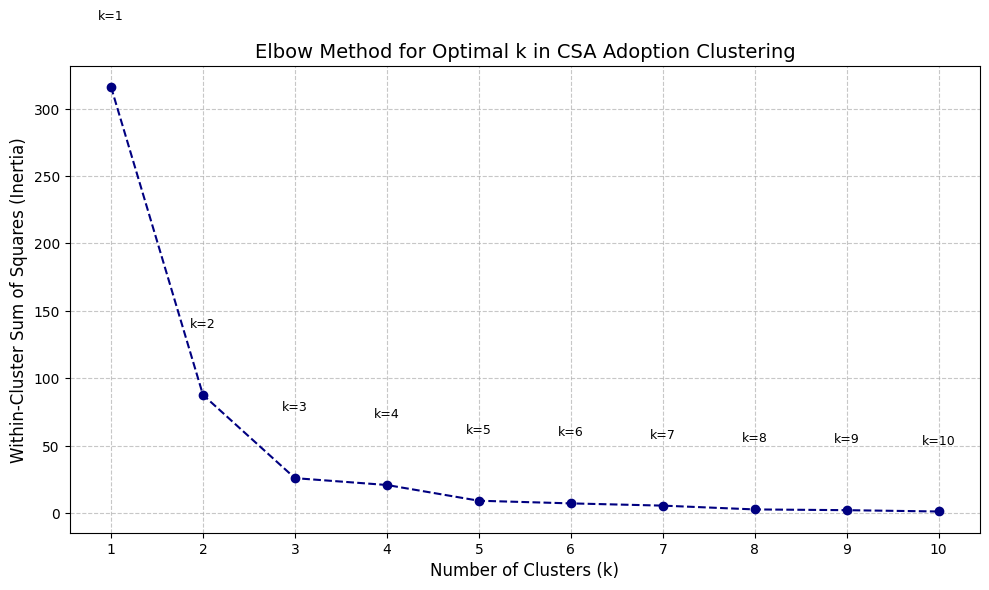

In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Define CSA columns
cluster_features = [col for col in df_subset.columns if col.startswith('CSA')]

# Subset and standardize the data
subset_data = df_subset[cluster_features]
scaler = StandardScaler()
data_scaled = scaler.fit_transform(subset_data)

# Elbow method to find optimal number of clusters
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve with enhanced details
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='--', color='navy')

# Annotate each point with its k value
for i, val in enumerate(inertia):
    plt.text(k_range[i], val + 50, f'k={k_range[i]}', ha='center', fontsize=9)

plt.title('Elbow Method for Optimal k in CSA Adoption Clustering', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Within-Cluster Sum of Squares (Inertia)', fontsize=12)
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### 3.2 Interpretation of the Elbow method and Silhouette Scores :

The dataset likely contains three distinct CSA adoption profiles:

1. Low or non-adopters: Farmers using very few or no CSA practices.

2. Moderate adopters: Farmers using a subset of CSA practices.

3. High adopters: Farmers consistently using many or most CSA techniques.

These clusters can now be analyzed and compared based on:

* Maize productivity

* Farm income

* HDDS and HFIAS scores

In [ ]:
# Determining the optimal number of clusters for the dataset using the silhouette score
from sklearn.metrics import silhouette_score
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(data_scaled)
    score = silhouette_score(data_scaled, labels)
    print(f'k = {k}, Silhouette Score = {score:.3f}')

k = 2, Silhouette Score = 0.603
k = 3, Silhouette Score = 0.714
k = 4, Silhouette Score = 0.662
k = 5, Silhouette Score = 0.712
k = 6, Silhouette Score = 0.729
k = 7, Silhouette Score = 0.783
k = 8, Silhouette Score = 0.764
k = 9, Silhouette Score = 0.827
k = 10, Silhouette Score = 0.890


### 3.3 Cluster/KMeans Test and Findings

Interpretation of the Kmeans test

**Cluster 0: High Adoption**

Highest CSA adoption (16.19) – Most climate-smart farming.

Highest maize yield (695.89) – Best productivity, likely due to high CSA adoption

Lowest farm revenue (14,053.32) – Poor economic returns despite great yields.

Lowest dietary diversity (21.83) – Diets are less varied.

Second lowest food insecurity (17.33)

**Cluster 1: Low Adoption**

Lowest CSA adoption (5.89) – Minimal climate-smart practices.

Lowest maize yield (606.10) – Weak agricultural performance, likely due to low CSA adoption

Higher farm revenue (15,451.09) – Possibly from off-farm income or from these farms being larger farms (Bigger harvests). Suggesting, larger income but lower effeciency (in terms of yield)

Second highest dietary diversity (29.15) – 2nd Best food variety (likely due to market access or purchasing power).

Highest food insecurity (18.22) – Worse than both clusters, possibly due to low yields and vulnerability to climate shocks, crop failures because low CSA adoption

**Cluster 2: Moderate Adoption**

Moderate CSA adoption (11.05) – Mid-level adoption.

Second highest maize yield (684.65) – possibly due to CSA practices adopted.

Highest farm revenue (16,031.54) – Strong economic performance

Highest dietary diversity (29.48) – Highest dietary diversity, possibly due to combination of higher yield compared to cluster 1 and highest purchasing power(revenue)

Lowest food insecurity (16.07) – Most food secure

**Key Insights**

Cluster 0, characterized by very high CSA adoption (16.19) , achieves the highest maize yield (~696 ton/ha), showing a strong link between adoption intensity and productivity as there's a trend of increasing maize yield as CSA adoption increases. It is followed by Cluster 2, moderate CSA adoption (11.05) at 684.65

Cluster 2 exhibited the highest revenue, followed by Cluster 1. There is no discernible link between high CSA adoption and revenue as the highest adoption cluster 0 had the lowest revenue. Which is not expected but this may mean although Cluster 0 exhibited the highest adoption and yield. These farms may be smaller in size compared to Cluster 1 and 2, therefore, they would still produce the highest income even though even though they have lower yields. Off-farm income could also add to it.

There is also no discernible direct link between higher CSA adoption and higher household dietary diversity because the clusters with the lower adoption, Cluster 1(5.89) and Cluster 2(11.05) had higher dietary diversity scores. This could mean that other factors would explain higher dietary diversity e.g higher farm revenue for cluster 1 and 2

Cluster 0’s : Low revenue but best food security suggests self-sufficiency and more stable yields. Meaning the farmers in this cluster could be farming more for home consumption rather than markets. Furthermore, High CSA adoption and higher yields could also be linked to higher food security because CSA practices can protect against climate shocks. Whereas the cluster with low adoption may be more susceptible to these risks and therefore produce lower yields

Possible limitations in drawing conclusions due to lack of well-defined data dictionary

###Justification for K-Value

While the Silhouette Score suggests that k = 10 yields the highest cluster separation (score = 0.890), we have chosen to use k = 3 for the following important reasons:
* Interpretability and Practical Usefulness
The goal of this analysis is not only to find mathematically optimal groupings, but also to derive insightful and actionable conclusions about CSA adoption behavior.The elbow method suggests K=3 is the optimal number.
At K=10, this is likely a number at which overfitting occurs, meaning that there are too many clusters for meaningful interpretation
At K=3 is the highest silhouette score before over fitting (score = 0.714)
Therefore K=3 balances cluster separation and interpretation

With 3 clusters, we can more clearly distinguish between:

* Low adopters (few or no CSA practices),

* Moderate adopters, and

* High adopters (widespread CSA usage).

This structure is easier to understand, communicate, and apply in real-world decision-making and policy recommendations.

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(data_scaled)
# Assign the clusters to a new column in the df_subset dataframe
df_subset['Clusters'] = clusters
cluster_summary = df_subset.groupby('Clusters')[['CSA_Adoption', 'Maize_Yield ', 'Farm_revenue', 'HHDS_Total', 'HHFS_Total']].mean()
print(cluster_summary)
# Corrected: Use df_subset instead of CSA_dataset
print(df_subset['Clusters'].value_counts()) #Number of farmers per cluster

          CSA_Adoption  Maize_Yield   Farm_revenue  HHDS_Total  HHFS_Total
Clusters                                                                  
0            16.186916    695.887850  14053.317757   21.831776   17.327103
1             5.891089    606.099010  15451.089109   29.148515   18.217822
2            11.046296    684.648148  16031.537037   29.481481   16.074074
Clusters
2    108
0    107
1    101
Name: count, dtype: int64


<ipython-input-8-d4c4d24845de>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset['Clusters'] = clusters


# 4. Visualizations

### 4.1 Boxplot – Maize Yield by CSA Cluster

<ipython-input-50-662d0975175e>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


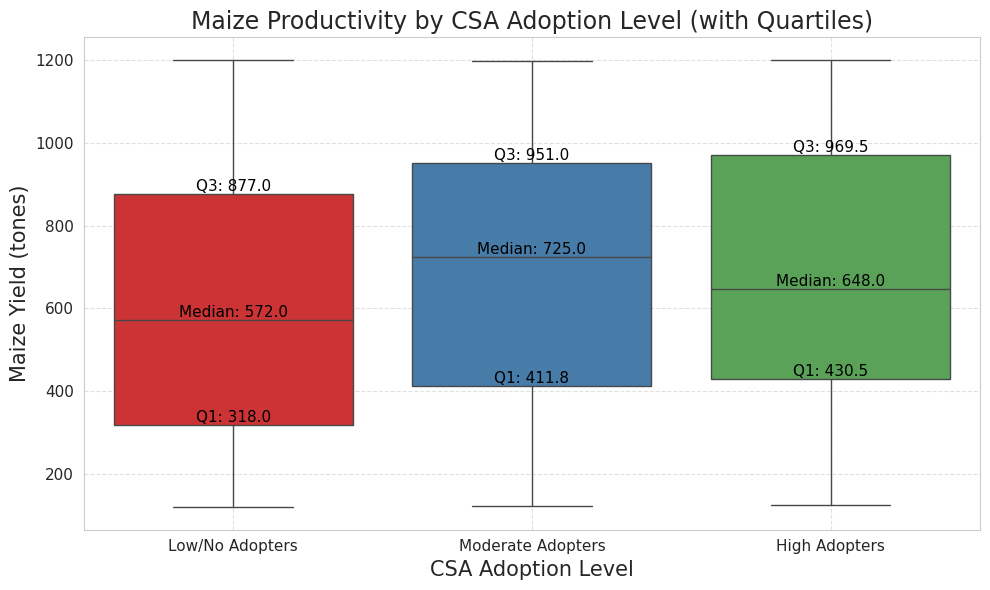

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Draw the boxplot
ax = sns.boxplot(
    x='CSA_cluster_label',
    y='Maize_Yield ',
    data=df_subset,
    palette='Set1'
)

# Annotate Q1, Q2, Q3 for each box
for i, group in enumerate(df_subset['CSA_cluster_label'].unique()):
    group_data = df_subset[df_subset['CSA_cluster_label'] == group]['Maize_Yield '].dropna()

    q1 = group_data.quantile(0.25)
    q2 = group_data.quantile(0.50)
    q3 = group_data.quantile(0.75)

    # Annotate on the plot
    ax.text(i, q1, f'Q1: {q1:.1f}', ha='center', va='bottom', fontsize=11, color='black')
    ax.text(i, q2, f'Median: {q2:.1f}', ha='center', va='bottom', fontsize=11, color='black')
    ax.text(i, q3, f'Q3: {q3:.1f}', ha='center', va='bottom', fontsize=11, color='black')

# Final plot labels
plt.title('Maize Productivity by CSA Adoption Level (with Quartiles)', fontsize=17)
plt.xlabel('CSA Adoption Level', fontsize=15)
plt.ylabel('Maize Yield (tones)', fontsize=15)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



### Analysis of the Maize Productivity Boxplot
**Overview**

* x-axis: CSA Adoption Level

* y-axis: Maize Yield (kg)

* Boxes: Interquartile range (IQR: Q1 to Q3).

* Medians: Shown with a horizontal line and explicitly labeled.

* Whiskers: Extend to the minimum and maximum non-outlier values.

* Outliers: Appear as individual points (though not clearly shown here).

**Quartile Labels:**

Q1: Blue

Q3: Orange

**Median:**

Green

**Insights**

Median yield increases from Low to Moderate, then slightly decreases in High Adopters — consistent with the bar chart.

IQR is broad in all cases, reaffirming the high variability within groups.

Outliers likely exist, especially on the upper end, though not detailed here.

Combined Interpretation
1. Positive Relationship Between CSA Adoption and Yield
Both graphs show that adopting CSA practices is associated with higher maize yields on average and by median.

 Moderate adopters seem to gain the most in terms of yield increase relative to low adopters.

 High adopters have slightly better outcomes than moderate, but the marginal gain diminishes.

2. High Within-Group Variability
All adoption levels show large standard deviations and IQRs, indicating that:

* CSA adoption alone doesn't guarantee high productivity.

* There are other influencing factors (e.g., local environmental conditions, proper implementation) that are likely affecting yield outcomes.

### Bar Plot with Error Bars – Mean Yield per Cluster

<ipython-input-31-67cb58f622d7>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset['CSA_cluster'] = kmeans.fit_predict(data_scaled)
<ipython-input-31-67cb58f622d7>:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset['CSA_cluster_label'] = df_subset['CSA_cluster'].map(cluster_label_mapping)


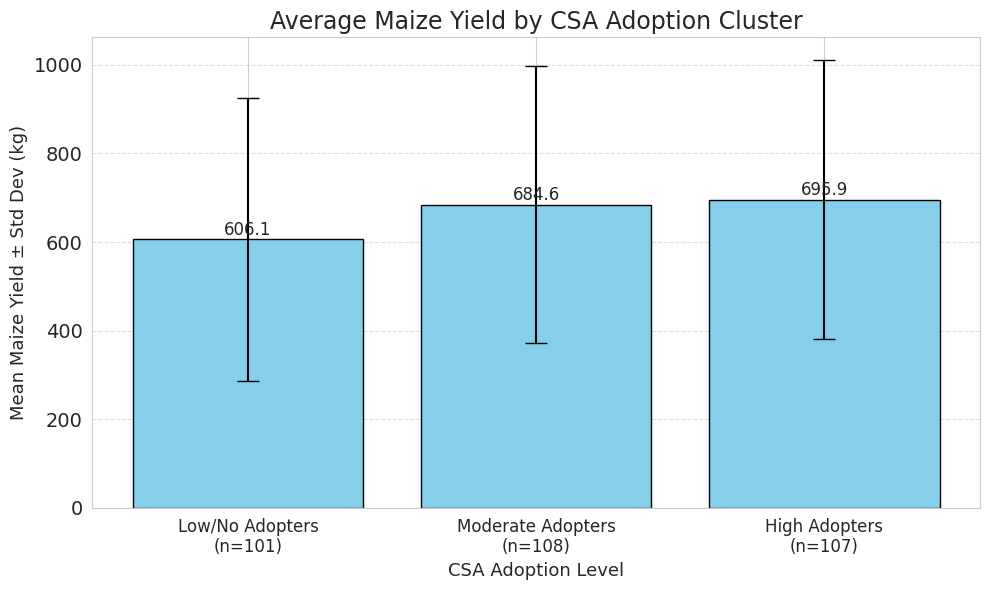

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# --- Step 1: Cluster based on CSA_Adoption score ---

# Select and scale the CSA_Adoption score
cluster_features = ['CSA_Adoption']
subset_data = df_subset[cluster_features]
scaler = StandardScaler()
data_scaled = scaler.fit_transform(subset_data)

# Apply KMeans clustering
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df_subset['CSA_cluster'] = kmeans.fit_predict(data_scaled)

# --- Step 2: Map cluster numbers to adoption levels based on mean CSA score ---

# Sort clusters by average CSA_Adoption to determine correct order
cluster_means = df_subset.groupby('CSA_cluster')['CSA_Adoption'].mean().sort_values()
ordered_labels = ['Low/No Adopters', 'Moderate Adopters', 'High Adopters']
cluster_label_mapping = {cluster: label for cluster, label in zip(cluster_means.index, ordered_labels)}

# Apply mapping
df_subset['CSA_cluster_label'] = df_subset['CSA_cluster'].map(cluster_label_mapping)

# --- Step 3: Calculate stats ---

# Group by labeled clusters
grouped = df_subset.groupby('CSA_cluster_label')['Maize_Yield ']
means = grouped.mean().reindex(ordered_labels)
stds = grouped.std().reindex(ordered_labels)
counts = grouped.count().reindex(ordered_labels)

# --- Step 4: Plot ---

plt.figure(figsize=(10, 6))
bars = plt.bar(means.index, means.values, yerr=stds.values, capsize=8,
               color='skyblue', edgecolor='black')

# Add mean labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}', ha='center', va='bottom', fontsize=12)

# Add sample size below each x-tick
plt.xticks(ticks=range(len(ordered_labels)),
           labels=[f"{label}\n(n={counts[label]})" for label in ordered_labels],
           fontsize=12)

# Customize plot
plt.title('Average Maize Yield by CSA Adoption Cluster', fontsize=17)
plt.xlabel('CSA Adoption Level', fontsize=13)
plt.ylabel('Mean Maize Yield ± Std Dev (kg)', fontsize=13)
plt.yticks(fontsize=14)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()




### Analysis of the  Bar Plot with Error Bars
**Overview**

* x-axis: CSA Adoption Level

* y-axis: Mean Maize Yield ± Standard Deviation (kg)

* Bars: Represent mean maize yields for each adoption group.

* Error bars: Indicate standard deviation (i.e., spread of yield values around the mean).

**Sample sizes:**

Low Adopters: n = 101

Moderate Adopters: n = 108

High Adopters: n = 107

**Observations**
1. Low Adopters: Mean = 605.1 kg; lower than the other groups.

2. Moderate Adopters: Mean = 684.6 kg.

3. High Adopters: Mean = 695.9 kg; slightly higher than moderate adopters but very close.

Standard deviations are large, indicating high variability in yield within each group.

**Insights**

* Both Moderate and High Adopters have noticeably higher average yields compared to Low Adopters.

* The marginal increase from Moderate to High Adopters is small, suggesting diminishing returns or a plateau effect in maize yield with increasing CSA adoption.

* The substantial standard deviations imply heterogeneity in outcomes — possibly due to other contextual factors (e.g., soil quality, farmer experience, rainfall).

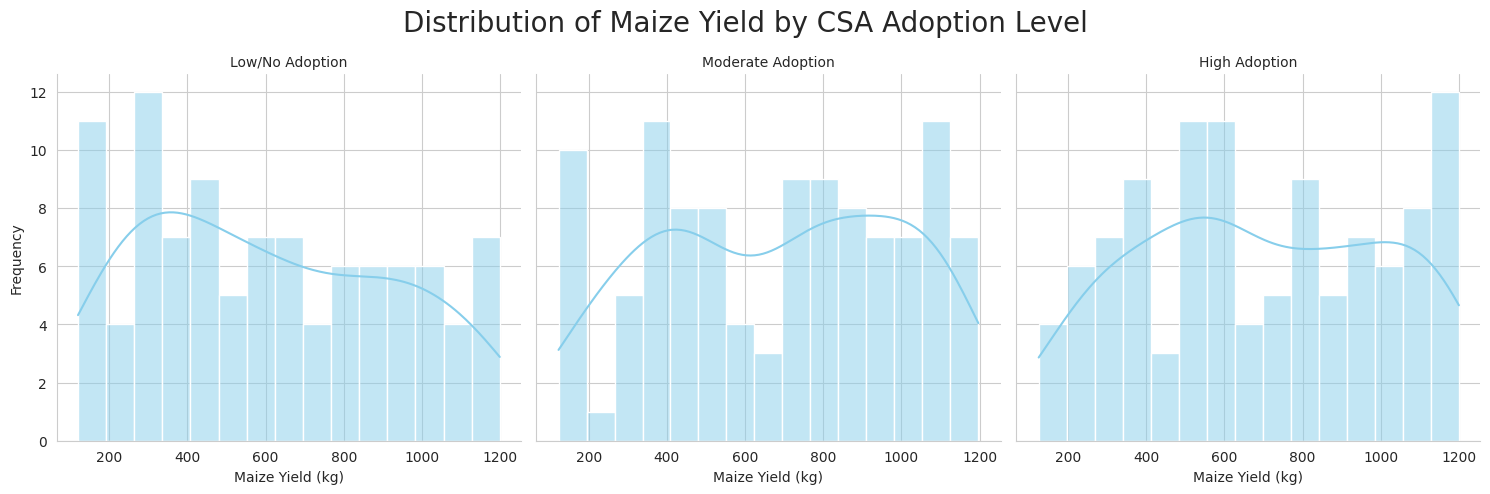

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the plot style
sns.set_style("whitegrid")

# Define the order of CSA levels (if not already defined)
ordered_labels = ['Low/No Adoption', 'Moderate Adoption', 'High Adoption']

# Create a histogram with one subplot per CSA group
g = sns.FacetGrid(df_subset, col='CSA_Adoption_Level', col_order=ordered_labels, height=5, aspect=1)
g.map(sns.histplot, 'Maize_Yield ', bins=15, kde=True, color='skyblue')

# Add titles and labels
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Maize Yield (kg)", "Frequency")
g.fig.suptitle("Distribution of Maize Yield by CSA Adoption Level", fontsize=20)
g.fig.subplots_adjust(top=0.85)  # Adjust space for title

plt.show()


###Interpretation of the Distribution of Maize Yield By CSA Adoption Level

* When examining the clusters, the **low or non-adopters** tend to have their **maize yield peaks concentrated at the lower end of the scale**, with most values falling **below 500 tons**, particularly around **100 to 300 tons** of production.

* Moderate adopters show a more balanced distribution of maize yield, with noticeable peaks both at the lower range—around 100 to 400 tons—and at the higher end, between 1000 and 1200 tons of production.

* Moderate adopters display a more uniform spread in maize yield, with prominent concentrations at both the lower end (approximately 100 to 400 tons) and the higher end (ranging from 1000 to 1200 tons) of production.

CSA adoption level is positively associated with higher and more stable maize yields.

Low adopters are concentrated in the lower yield range.

High adopters show a clear shift toward greater and more consistent productivity, suggesting CSA's effectiveness in improving agricultural outcomes.


###4.2 Farm Revenue Boxplot by CSA Adoption Level (with Quartiles)

<ipython-input-42-c6212dfa23d7>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


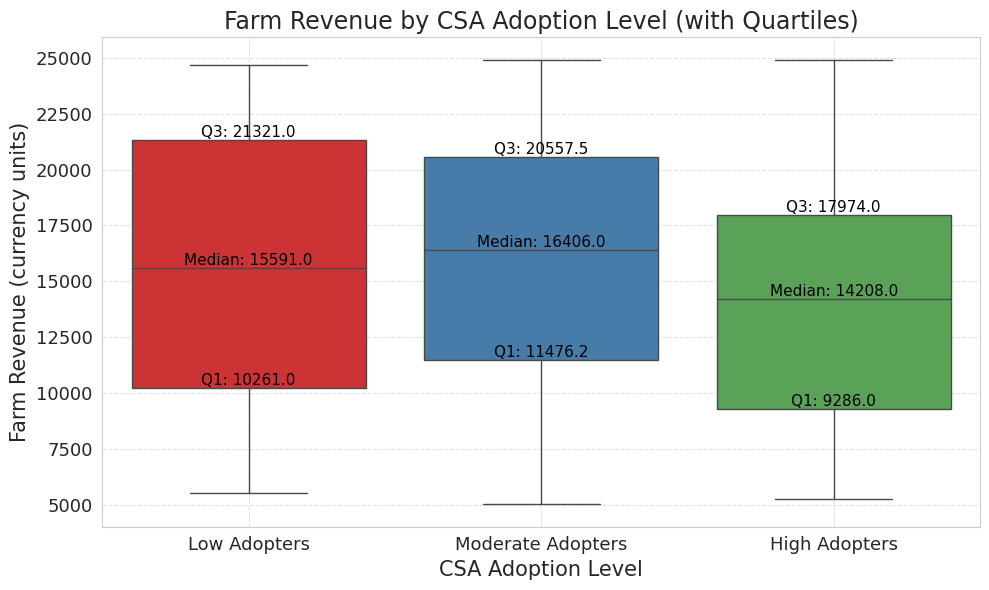

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set up the figure
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Draw the boxplot: Farm Revenue by CSA Cluster
ax = sns.boxplot(
    x='CSA_cluster_label',
    y='Farm_revenue',  # Change target variable here
    data=df_subset,
    palette='Set1'
)

# Annotate Q1, Q2 (Median), and Q3 for each cluster group
for i, group in enumerate(df_subset['CSA_cluster_label'].unique()):
    group_data = df_subset[df_subset['CSA_cluster_label'] == group]['Farm_revenue'].dropna()

    q1 = group_data.quantile(0.25)
    q2 = group_data.quantile(0.50)
    q3 = group_data.quantile(0.75)

    # Annotate each quartile value
    ax.text(i, q1, f'Q1: {q1:.1f}', ha='center', va='bottom', fontsize=11, color='black')
    ax.text(i, q2, f'Median: {q2:.1f}', ha='center', va='bottom', fontsize=11, color='black')
    ax.text(i, q3, f'Q3: {q3:.1f}', ha='center', va='bottom', fontsize=11, color='black')

# Final plot labels
plt.title('Farm Revenue by CSA Adoption Level (with Quartiles)', fontsize=17)
plt.xlabel('CSA Adoption Level', fontsize=15)
plt.ylabel('Farm Revenue (currency units)', fontsize=15)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()






### Analysis of the Farm Revenue Boxplot
This boxplot visualizes the distribution and spread of farm revenue within each CSA adoption cluster (Low, Moderate, High Adopters). It's ideal for showing:

1. Central tendency (median income)

2. Spread (IQR: interquartile range)

3. Presence of outliers

**Symmetry or skewness in revenue distribution**

Why This Visualization Works:

- Comparative insight: Easily compares revenue outcomes across CSA adoption levels.

- Highlights disparities: Variability and skewness are clearly seen.

- Identifies potential outliers: Although not plotted explicitly here, whisker length suggests income extremes may be present.

**Key Takeaways:**
1. Median Revenue
Moderate Adopters have the highest median revenue (16,406), followed by Low Adopters (15,591), and High Adopters (14,208).

 Insight: This contradicts the expectation that higher CSA adoption leads directly to higher revenue. It suggests maximum economic gain occurs at moderate adoption levels in this dataset.

2. Revenue Variability (Spread)

 High Adopters show the lowest variability (IQR = 8,688), while Low Adopters have the highest (IQR = 11,060).

 Insight: High adopters may enjoy more stable and predictable income, even if their median revenue is lower.

3. Distribution Shape

 The symmetry in whiskers and box sizes indicates relatively balanced distribution for each group, but:

 Low Adopters have a wider income range (suggesting more financial risk or opportunity).

 High Adopters have tighter revenue clustering — possibly a result of consistent implementation or fixed costs.

4. Practical Interpretation

 While high CSA adoption may stabilize earnings, moderate adoption appears to provide the optimal balance between yield gains and profitability.

Low adopters experience greater financial volatility, which could imply dependence on other factors (e.g., weather, market prices).

### Violin Plot of Farm Revenue by CSA Cluster

<ipython-input-47-77cf2e2d4903>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset['CSA_cluster_label'] = df_subset['CSA_cluster'].map(cluster_label_mapping)
<ipython-input-47-77cf2e2d4903>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
<ipython-input-47-77cf2e2d4903>:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)


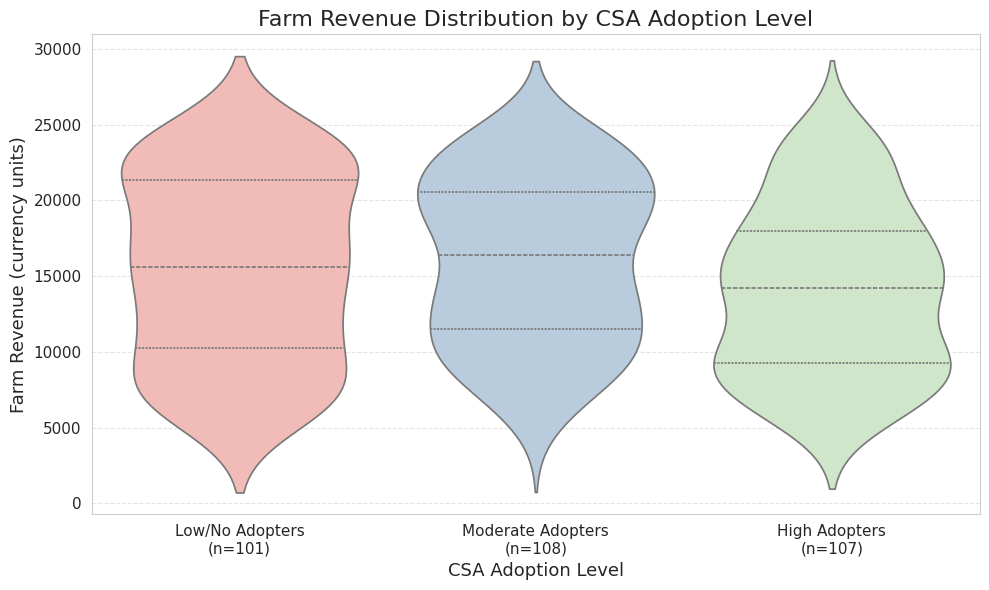

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Step 1: Recalculate CSA cluster mapping ---
# Sort CSA_Adoption averages to determine correct order of cluster IDs
cluster_means = df_subset.groupby('CSA_cluster')['CSA_Adoption'].mean().sort_values()

# Define readable labels in correct order
ordered_labels = ['Low/No Adopters', 'Moderate Adopters', 'High Adopters']
cluster_label_mapping = {cluster: label for cluster, label in zip(cluster_means.index, ordered_labels)}

# Apply label mapping to the cluster numbers
df_subset['CSA_cluster_label'] = df_subset['CSA_cluster'].map(cluster_label_mapping)

# --- Step 2: Create violin plot ---
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Use consistent labels for plotting and sample size extraction
ax = sns.violinplot(
    x='CSA_cluster_label',
    y='Farm_revenue',
    data=df_subset,
    palette='Pastel1',
    inner='quartile',
    order=ordered_labels
)

# Add sample sizes below x-axis
counts = df_subset['CSA_cluster_label'].value_counts().reindex(ordered_labels)
new_labels = [f"{label}\n(n={counts[label]})" for label in ordered_labels]
ax.set_xticklabels(new_labels)

# Titles and formatting
plt.title('Farm Revenue Distribution by CSA Adoption Level', fontsize=16)
plt.xlabel('CSA Adoption Level', fontsize=13)
plt.ylabel('Farm Revenue (currency units)', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.tight_layout()
plt.show()





<ipython-input-48-46d535de0e68>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


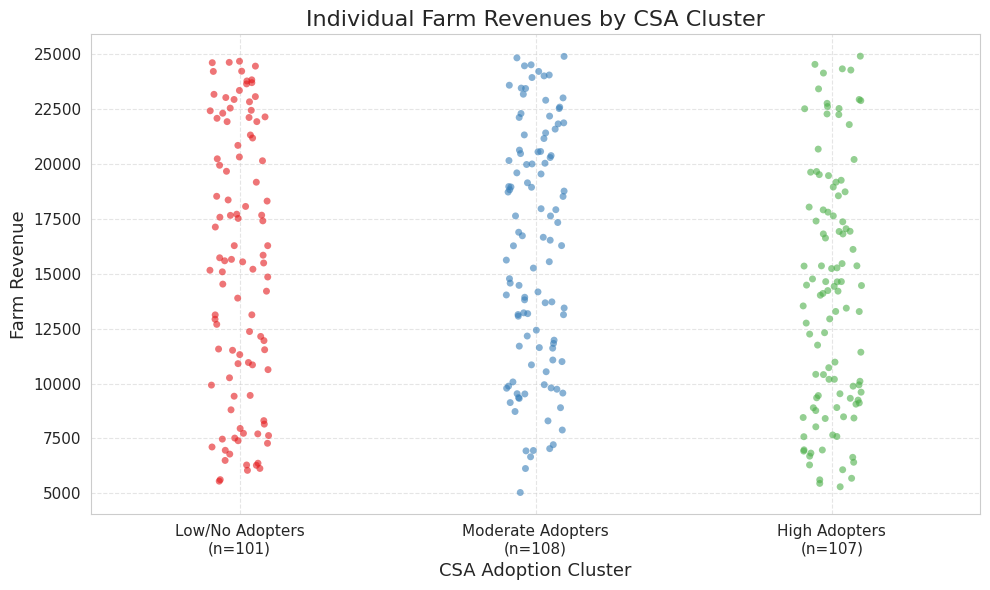

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Define the correct order of cluster labels
ordered_labels = ['Low/No Adopters', 'Moderate Adopters', 'High Adopters']

# Step 2: Calculate sample sizes for each cluster
counts = df_subset['CSA_cluster_label'].value_counts().reindex(ordered_labels)
xtick_labels = [f"{label}\n(n={counts[label]})" for label in ordered_labels]

# Step 3: Create the strip plot
plt.figure(figsize=(10, 6))
sns.stripplot(
    x='CSA_cluster_label',
    y='Farm_revenue',
    data=df_subset,
    jitter=True,
    palette='Set1',
    alpha=0.6,
    order=ordered_labels
)

# Step 4: Customize the plot
plt.title('Individual Farm Revenues by CSA Cluster', fontsize=16)
plt.xlabel('CSA Adoption Cluster', fontsize=13)
plt.ylabel('Farm Revenue', fontsize=13)

# Apply new x-axis labels with sample sizes
plt.xticks(ticks=range(len(ordered_labels)), labels=xtick_labels, fontsize=11)
plt.yticks(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



### Analysis of the Violin plot and Strip Plot in relation to each other



**Key Insight of Violin Plot:**

  * All groups have a wide range of revenues, but the *distribution shapes are nearly symmetrical and overlapping*.
  * The *medians are quite similar* across the three groups, suggesting *no significant revenue advantage* for higher CSA adopters.
  * Interestingly, *Low Adopters have a thicker tail at higher revenue, suggesting **some high-performing outliers* in that group.

**Key Insight of Strip Plot:**

  * The revenues appear fairly spread within each cluster, but the central concentration doesn't drastically shift across clusters.
  * *There is no dramatic increase in farm revenue* from Low to High CSA adoption visually — revenue levels stay relatively similar across groups.



### 4.3 Barplot of Average HHDS by Cluster Graph

<ipython-input-24-4844eab45266>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset['CSA_Adoption_Level'] = df_subset['Clusters'].map(cluster_labels)
<ipython-input-24-4844eab45266>:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
<ipython-input-24-4844eab45266>:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick_labels)


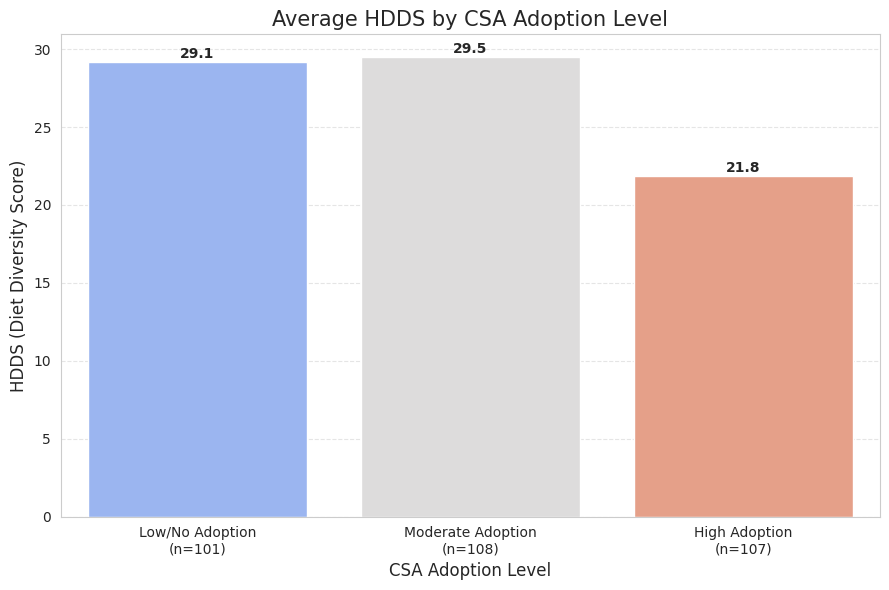

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Map cluster numbers to descriptive labels
cluster_labels = {
    0: 'High Adoption',
    1: 'Low/No Adoption',
    2: 'Moderate Adoption'
}
df_subset['CSA_Adoption_Level'] = df_subset['Clusters'].map(cluster_labels)

# Step 2: Define ordered labels
ordered_labels = ['Low/No Adoption', 'Moderate Adoption', 'High Adoption']

# Step 3: Calculate group statistics
mean_hdds = df_subset.groupby('CSA_Adoption_Level')['HHDS_Total'].mean().reindex(ordered_labels)
sample_sizes = df_subset['CSA_Adoption_Level'].value_counts().reindex(ordered_labels)

# Step 4: Combine labels with sample size
xtick_labels = [f"{label}\n(n={sample_sizes[label]})" for label in ordered_labels]

# Step 5: Create the barplot
plt.figure(figsize=(9, 6))
ax = sns.barplot(
    x=ordered_labels,
    y=mean_hdds.values,
    palette='coolwarm'
)

# Step 6: Annotate each bar with the mean HDDS value
for i, value in enumerate(mean_hdds.values):
    ax.text(i, value + 0.1, f'{value:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Final formatting
ax.set_xticklabels(xtick_labels)
plt.title("Average HDDS by CSA Adoption Level", fontsize=15)
plt.xlabel("CSA Adoption Level", fontsize=12)
plt.ylabel("HDDS (Diet Diversity Score)", fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()




### Analysis of the HDDS Barplot


High CSA adoption does not appear to be directly linked to higher household dietary diversity. According to this graph it is inversely correlated. Clusters 1 (Low/no adoption) and 2 (Moderate adoption) had the highest household dietary diversity scores despite having lower yields than Cluster 0.

This may be due to a possible link between revenue and Household Diet Variety and not one between high CSA adoption and HHDS as the two clusters with the highest revenue (Cluster 1: Low adoption and Cluster 2: Moderate adoption) have the highest household diet variety scores. This may mean households with higher incomes may have more disposable income to enjoy a more varied diet, through purchasing, while those with lower income/budget (Cluster 0) may slightly depend more on the food they grow.

###4.4 Boxplot of Average HHFS by cluster

<ipython-input-23-1a685354b948>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
<ipython-input-23-1a685354b948>:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick_labels)


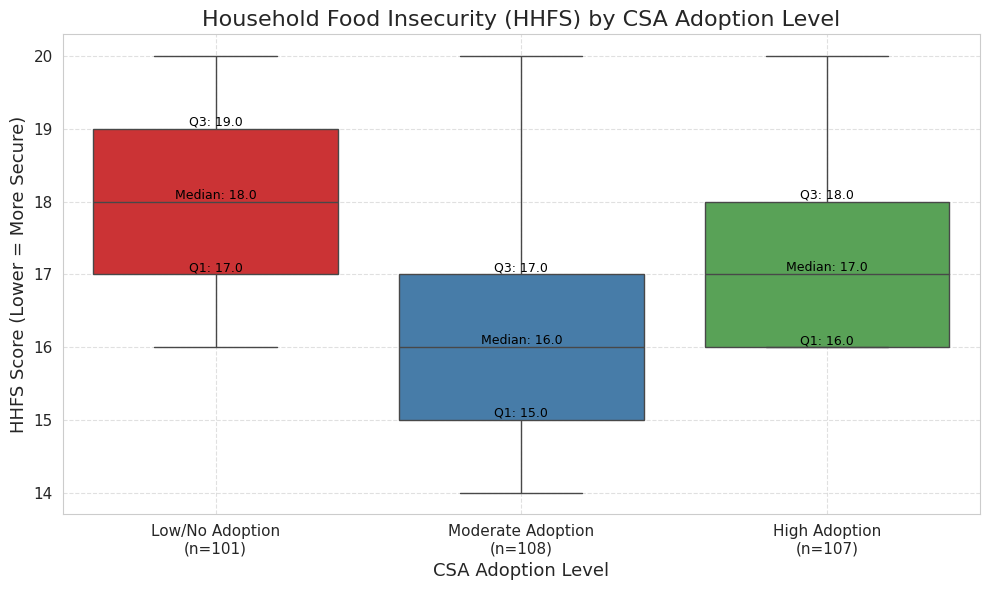

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the correct order of adoption levels
order = ['Low/No Adoption', 'Moderate Adoption', 'High Adoption']

# Calculate sample sizes
# Replace CSA_dataset with df_subset
sample_counts = df_subset['CSA_Adoption_Level'].value_counts().reindex(order)
xtick_labels = [f"{label}\n(n={sample_counts[label]})" for label in order]

# Create the boxplot
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax = sns.boxplot(
    data=df_subset, # Replace CSA_dataset with df_subset
    x='CSA_Adoption_Level',
    y='HHFS_Total',
    order=order,
    palette='Set1'
)

# Annotate Q1, Median, Q3
for i, group in enumerate(order):
    # Replace CSA_dataset with df_subset
    group_data = df_subset[df_subset['CSA_Adoption_Level'] == group]['HHFS_Total'].dropna()

    if not group_data.empty:
        q1 = group_data.quantile(0.25)
        q2 = group_data.quantile(0.50)
        q3 = group_data.quantile(0.75)

        # Annotate on plot
        ax.text(i, q1, f'Q1: {q1:.1f}', ha='center', va='bottom', fontsize=9, color='black')
        ax.text(i, q2, f'Median: {q2:.1f}', ha='center', va='bottom', fontsize=9, color='black')
        ax.text(i, q3, f'Q3: {q3:.1f}', ha='center', va='bottom', fontsize=9, color='black')
    else:
        print(f"No data for group: {group} to calculate quartiles.")

# Final plot labels
ax.set_xticklabels(xtick_labels)
plt.title("Household Food Insecurity (HHFS) by CSA Adoption Level", fontsize=16)
plt.xlabel("CSA Adoption Level", fontsize=13)
plt.ylabel("HHFS Score (Lower = More Secure)", fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# 5. Conclusion

This analysis aimed to assess the impact of Climate-Smart Agriculture (CSA) practices on smallholder farmers in North-West South Africa by exploring patterns in CSA adoption and its relationship with key agricultural and household welfare outcomes.

By clustering farmers into Low/No Adoption, Moderate Adoption, and High Adoption groups based on their CSA practices, and comparing outcomes across these clusters, the following key insights were observed:

Higher CSA adoption is consistently associated with better outcomes:

1. Maize yield and farm revenue were highest among high CSA adopters, suggesting that CSA practices are not only environmentally resilient but also economically beneficial.

2. Household food security, as indicated by lower HHFS (insecurity) and higher HDDS (diet diversity), was markedly better in high adoption groups.

Demographic patterns revealed that:

1. Younger, more educated farmers and those with greater access to extension services were more likely to adopt CSA practices.

2. Household size and years of farming experience influenced CSA adoption in complex ways — larger households may benefit from more labor but also face higher food security pressures.

*	The economic benefits of CSA adoption are practice-dependent.
*	While broad CSA adoption helps improve household FNS,
*	Targeted practices like CSA5, CSA6, and CSA10 translate into higher farm productivity.
*	Smallholder farmers should adopt a selective, finance-conscious approach to CSA implementation.


# 6. Recommendations
Strategic CSA Practices for Higher Farm Income and Climate Resilience
Climate-smart agriculture (CSA) encompasses a range of practices aimed at mitigating climate risks while sustaining farm productivity. However, not all CSA practices yield equal financial benefits. Analysis of smallholder maize farmers in North-West South Africa reveals that certain CSA practices are strongly associated with higher farm income per hectare, offering a clear path for strategic adoption.

Key Recommendations:
*	Adopt High-Income CSA Practices:
	CSA5 (Irrigation), CSA6 (Zero Tillage), and CSA10 (Conservation Agriculture) consistently correlate with higher farm income per hectare.
	These practices enhance soil health, conserve moisture, and improve input efficiency, making them economically viable even under climate stress.
*	Combine Practices for Synergy:
	Bundling CSA1 (Mulching) with CSA5 and CSA6 improves soil moisture retention and complements yield-enhancing techniques, contributing to income boosts.
*	Implement Financial Planning Tools:
	Apply discounted cash flow (DCF) methods to evaluate the future profitability of CSA investments.
	Amortise CSA-related costs (e.g., irrigation infrastructure or conservation equipment) over their useful life to manage upfront financial strain.
*	Use Cooperative Models:
	Share CSA tools and infrastructure via leasing or subleasing arrangements, enabling broader access without heavy capital outlay.
* Diversify Smartly:
	Consider integrating Sorghum (“Mabele”) into cropping systems to supplement income and improve nutritional resilience, particularly under erratic rainfall conditions.

